# Probabilistic Association to Hosts Module

We use the Bayesian Probabilistic Association of Transients to their Hosts (PATH) formalism to identify the host galaxy and estimate its probability of association ([Aggarwal+2021](https://ui.adsabs.harvard.edu/abs/2021ApJ...911...95A)). This formalism invokes Bayes' rule to calculate the posterior probability $P(O_i|x)$, where $O_i$ is the case that the FRB is from galaxy $i$ and $x$ represents the observables such as **FRB localization**, **galaxy coordinates**, **magnitude**, and **angular size**.

### Objective
Identify and measure the FRB host galaxy association probability.

### Required dependencies
All the software required for today's tutorials should be readily accessible in the docker containers. Here, we link to the official webpages of all the software for future reference.

* [astropath](https://github.com/FRBs/astropath) for computing the host association probability, and
* [photutils](https://photutils.readthedocs.io/en/stable/) to overlay apertures.

The following cell imports all of these packages for this module. Kindly ensure all these imports go through successfully. If you encounter any issues with the software, please reach out to the nearest Docker expert for assistance.



In [1]:
import numpy as np
import os
import pandas as pd
import astropy.units as u
from astropy import coordinates
from astropy.wcs import WCS
from astropy.io import fits
from astropy.table import Table
from astropy.stats import sigma_clipped_stats, sigma_clip
from photutils.aperture import EllipticalAperture, SkyCircularAperture

from astropath import path
from astropath import localization

import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger().setLevel(logging.ERROR)

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk')
sns.set(font_scale=1.4)
sns.set_palette('colorblind')
sns.set_style('ticks')
plt.rcParams["font.family"] = "Times New Roman"
cmap = matplotlib.cm.get_cmap('rainbow')


Lets load in the localization of FRB Mizu from DSA-110 radio interferometer.

In [2]:
def get_ra_dec_errs(frb_name):
    """
    Returns:
    -------
    position0 : SkyCoord
        SkyCoord object representing the voltage localization.
    e_ra      : float
        Error in right ascension (RA).
    e_dec     : float
        Error in declination (Dec).
    """
    # Read the FRBs data sheet
    dsa_radio_sheet = pd.read_excel('data/DSA110-FRBs.xlsx', 
                                    sheet_name='frb_params', engine='openpyxl', 
                                    keep_default_na=False, na_values='')
    
    # Drop the first row (assuming it contains headers or irrelevant data)
    dsa_radio_sheet = dsa_radio_sheet.drop(0)
    
    # Filter the data by FRB name
    df = dsa_radio_sheet[dsa_radio_sheet["Nickname"]==frb_name].reset_index()
    
    # Convert DataFrame to astropy Table
    tbl = Table.from_pandas(df)
    tbl.rename_column('Nickname', 'Name')
    
    # Extract relevant columns
    nicknames = tbl['Name'].tolist()
    position0 = [coordinates.SkyCoord(tbl[i]['Voltage localization'].replace('\u200b', '', 2))
                 for i in range(len(tbl))]
    
    # Ensure consistency between nicknames and positions
    assert len(nicknames) == len(position0)
    
    # Extract position errors
    epos = tbl['Position error (1sigma)']
    for row in epos:
        if isinstance(row, str):
            er, ed = row.split(',')
            e_ra = float(er)
            if ed == ' 1.4 (nominal)':
                e_dec = 1.4
            else:
                e_dec = float(ed)
        else:
            e_ra = 1
            e_dec = 0.7
    
    return position0, e_ra, e_dec


nickname = 'mizu'
position0, e_ra, e_dec = get_ra_dec_errs(nickname)
print(position0, e_ra, e_dec)
tabr = pd.DataFrame(zip([position0], [e_ra], [e_dec]), columns=['RADEC', 'E_RA', 'E_DEC'])


[<SkyCoord (ICRS): (ra, dec) in deg
    (143.98395833, 73.28466667)>] 1.1 1.0


In [3]:
def get_rad(tabr):
    """ 
    RA, DEC in degrees.
    E_RA, E_DEC in degrees.
    """

    Path = path.PATH()
    co_rad = coordinates.SkyCoord(tabr.iloc[0]['RADEC'])
    eellipse = dict(a=tabr.iloc[0]['E_RA'], b=tabr.iloc[0]['E_DEC'], theta=0.)
    Path.init_localization('eellipse', center_coord=co_rad, eellipse=eellipse)
    return Path, co_rad

Path, co_rad = get_rad(tabr)

We use $r$-band magnitudes for our PATH analysis. When the deepest available imaging is PS1 or BASS $r$-band, we use their respective published source catalogs to identify the set of candidate host galaxies within 30" of the localization. 

* For PS1, one can query `VizieR` ([Ochsenbein+2000](https://ui.adsabs.harvard.edu/abs/2000A&AS..143...23O)
) using `Astropy` ([Astropy Collaboration+2013](https://ui.adsabs.harvard.edu/abs/2013A&A...558A..33A), [Astropy Collaboration+2018](https://ui.adsabs.harvard.edu/abs/2018AJ....156..123A)) and remove point sources using the PS1-Point Source Catalog ([Tachibana+2018](https://ui.adsabs.harvard.edu/abs/2018PASP..130l8001T)) queried using `CasJobs` ([OMullane+2005](https://ui.adsabs.harvard.edu/abs/2005cs........2072O)).

* For BASS, we extract the DR9 source catalog from [Legacy Survey Browser](https://www.legacysurvey.org/viewer?ra=247.5883&dec=70.2066&layer=ls-dr9&zoom=16#143.98395833%2073.2846666) ([Schlegel+2021](https://ui.adsabs.harvard.edu/abs/2021AAS...23723503S)) and identify galaxy candidates using the `Tractor` morphological classifications. We use the cataloged half-light radii and photometry in our PATH analysis.

* For FRB fields with deeper imaging from our follow-up campaigns, we obtain the astrometry solution using `astrometry.net` ([Lang+2010](https://doi.org/10.1088/0004-6256/139/5/1782)). We use `SExtractor` ([Bertin+2011](https://ui.adsabs.harvard.edu/abs/2011ASPC..442..435B)) to extract all $\geq2\sigma$ sources in the field and remove point sources using the `CLASS_STAR` classifier with an $85$% threshold. The source magnitudes are calibrated by correcting for zero points computed by cross-matching `SExtractor`-identified sources with the #II/349/ps1 catalog ([Flewelling+2018](https://ui.adsabs.harvard.edu/abs/2018AAS...23143601F)). The half light radii are measured by iteratively fitting elliptical isophotes using standard procedures defined in `photutils` ([Bradley+2022](https://doi.org/10.5281/zenodo.6825092)).


(2165.105134165295, 2397.6632737001787)

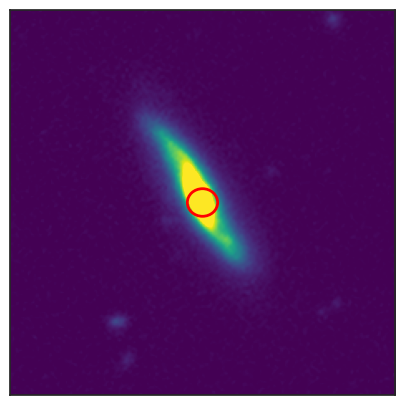

In [4]:
imageName = 'data/r.fits'.format(nickname)
f = fits.open(imageName)
data = f[1].data
header = f[1].header
w = WCS(header)

mean, median, sigma = sigma_clipped_stats(data)

fig = plt.figure(figsize=(5, 5)); ax = plt.subplot()
ax.imshow(data, vmin=median-0*sigma, vmax=median+100*sigma, cmap='viridis')

x0, y0 = w.world_to_pixel(co_rad[0])
aper = EllipticalAperture((x0, y0), e_ra*2.15/0.258, e_dec*2.15/0.258, 0)
aper.plot(color='red', linewidth=2)

ax.set_xticks([]); ax.set_yticks([])
size = 30/0.258
ax.set_xlim(x0-size, x0+size); ax.set_ylim(y0-size, y0+size)


## The PATH Framework

The Probabilistic Association of Transients to their Hosts (PATH; [Aggarwal+2021](https://ui.adsabs.harvard.edu/abs/2021ApJ...911...95A)) is a Bayesian framework developed to quantify the probability that a fast radio burst (FRB) is associated with a candidate host galaxy. 
Unlike earlier approaches based solely on chance coincidence probabilities, PATH assigns a full posterior probability 
distribution over possible hosts using simple observables: the FRB localization $(\alpha_{\rm FRB}, \delta_{\rm FRB}, \sigma_{\rm FRB})$, 
the candidate galaxy positions $(\alpha_i, \delta_i)$, their apparent magnitudes $m_i$, and their angular sizes $f_i$.

Formally, one considers the hypotheses that the FRB originates from galaxy $i$ (denoted $O_i$) or that its host is 
unobserved ($U$). Their prior probabilities satisfy
\begin{equation}
    P(U) + \sum_i P(O_i) = 1.
\end{equation}
More on the specifications of priors below!

Given a data vector $x$ representing the measured FRB position, Bayes' theorem yields the posterior probabilities:
\begin{align}
    P(U|x) &= \frac{P(U)\, p(x|U)}{p(x)} , \\
    P(O_i|x) &= \frac{P(O_i)\, p(x|O_i)}{p(x)} ,
\end{align}
with the normalization
\begin{equation}
    p(x) = P(U)\,p(x|U) + \sum_i P(O_i)\, p(x|O_i) ,
\end{equation}
ensuring that 
\begin{equation}
    P(U|x) + \sum_i P(O_i|x) = 1 .
\end{equation}

The likelihood term $p(x|O_i)$ encodes both the astrometric uncertainty of the FRB and the geometric/physical 
distribution of FRBs relative to the galaxy. If $\omega$ is the FRB direction, then
\begin{equation}
    p(x|O_i) = \int d\omega \; p(\omega|O_i)\, L(x - \omega) ,
\end{equation}
where $L(x-\omega)$ is the FRB localization error distribution and $p(\omega|O_i)$ describes the offset model for FRBs 
with respect to galaxy $i$ (e.g., uniform, exponential, or core-like distributions scaled by the galaxy’s half-light radius).

This probabilistic approach allows PATH to 
* account for multiple candidate galaxies in crowded fields, 
* incorporate prior knowledge such as galaxy brightness distributions, and 
* remain extendable to include additional observables such as dispersion measure (DM). 

The output is a calibrated posterior probability $P(O_i|x)$ for each candidate host, enabling statistically robust host associations of FRBs.

## Priors on Host Brightness and Offset Distributions

The PATH formalism incorporates simple, physically motivated priors to reflect the likelihood of a galaxy being an FRB host. Two commonly used priors are based on galaxy brightness and on the distribution of offsets between the FRB position and the galaxy centroid.

### Brightness Distribution Prior
Inspired by the classical chance-coincidence probability, PATH adopts a prior that favors brighter galaxies, since they are rarer on the sky. If $\Sigma(m)$ is the surface density of galaxies brighter than magnitude $m$, the prior probability for galaxy $i$ is taken as
\begin{equation}
    P(O_i) \propto \frac{1}{\Sigma(m_i)} ,
\end{equation}
where $m_i$ is the apparent magnitude of the candidate galaxy. This weighting scheme ensures that intrinsically brighter galaxies, which are less common, are assigned higher prior probability as potential hosts. Normalization of the prior is set by the constraint
\begin{equation}
    P(U) + \sum_i P(O_i) = 1 .
\end{equation}

### Host Offset Distribution
FRBs are expected to occur within or near galaxies, motivating offset priors $p(\omega|O_i)$ that decrease with increasing angular separation $\theta$ from the galaxy centroid, normalized by the galaxy half-light radius $f$. PATH considers several possible forms:

* **Uniform model**:
\begin{equation}
    p(\omega|O_i) = \frac{1}{\pi \theta_{\max}^2} \quad \text{for } \theta < \theta_{\max} ,
\end{equation}
which corresponds to a flat probability density within a circular aperture of radius $\theta_{\max}$.

* **Core (power-law) model**:
\begin{equation}
    p(\omega|O_i) = \frac{1}{2 \log(1+\theta_{\max}/f)} \,
    \frac{1}{\theta+f} ,
\end{equation}
which falls off approximately as $1/\theta^2$ at large separations.

* **Exponential model**:
\begin{equation}
    p(\omega|O_i) = \frac{1}{2 f^2} \,
    \frac{\exp\!\left[-(\theta/f)\right]}{1 - \exp\!\left(-\theta_{\max}/f\right)} ,
\end{equation}
which strongly favors FRBs near the galaxy center and declines exponentially with offset.


All offset functions are normalized such that
\begin{equation}
    \int_0^{\theta_{\max}} p(\omega|O_i)\, 2\pi \theta \, d\theta = 1 .
\end{equation}

These priors capture different physical scenarios: the uniform model corresponds to FRBs distributed throughout 
the galaxy extent, the core model mimics a broader distribution such as stellar halos, while the exponential model 
represents FRBs tracing stellar light more closely.


**The key observables in our analysis include the candidate host magnitude ($m$), host-normalized offsets ($\theta/\phi$), and the probability of non-detection of the host galaxy due to limited imaging depth $P(U)$.**

In [5]:
def load_fits_file(file_path):
    with fits.open(file_path, memmap=True) as hdu_list:
        data = hdu_list[1].data
        # Check endianness
        if data.dtype.byteorder not in ('=', '|'):
            data = data.byteswap().newbyteorder()
        tabo = Table(data)
    return tabo

tabo = load_fits_file("data/{}_cat.fits".format(nickname, nickname))
sel = (tabo["type"] == "REX") + (tabo["type"] == "DEV")+ (tabo["type"] == "EXP") + (tabo["type"] == "SER")
tabo = tabo[sel]
tabo["mag_r"] = np.log10(tabo["flux_r"]*1e-9)/-0.4

co_gals = coordinates.SkyCoord(ra=tabo["ra"], dec=tabo["dec"], unit="deg")

tabo = pd.DataFrame({"raMean": np.array(tabo["ra"], dtype="<f4"), 
                     "decMean": np.array(tabo["dec"], dtype="<f4"), 
                     "rKronMag": np.array(tabo["mag_r"], dtype="<f4"), 
                     "rKronRad": np.array(tabo["shape_r"], dtype="<f4"), 
                     "sep": np.array(co_gals.separation(co_rad).to_value("arcsec"), dtype="<f4")}).reset_index()
tabo = tabo[tabo["sep"]<60] # Pick all galaxies within 60 arcsec
tabo


,index,raMean,decMean,rKronMag,rKronRad,sep
0,0,143.968613,73.286591,23.553823,0.667175,17.326143
1,1,143.973541,73.286072,22.268047,0.474292,11.914756
2,2,143.979355,73.287193,23.196890,0.844649,10.270014
3,3,143.984589,73.284950,15.440931,7.429181,1.220825
4,4,143.989578,73.283813,22.209066,0.352957,6.572427


Since the true angular distribution of FRBs is unknown, we assume an exponential host-normalized offset distribution ($\theta/\phi$) and assert a maximum offset of $\theta_{\mathrm{max}} = 6\phi$. Although quantifying $P(U)$ is tricky, incorporating the probability of host invisibility in optically-limited data has crucial implications on (but not limited to) offsets and host galaxy properties distributions. We adopt $P(U) = 0.2$ for PS1 and $P(U) = 0.1$ for deeper BASS, WIRC, and WaSP imaging based on tests with simulated FRB populations ([Seebeck+2021](https://ui.adsabs.harvard.edu/abs/2021arXiv211207639S)).


In [6]:
def set_priors(Path, tabo, Pcand='inverse', PU=0., Poffset='exp', Poffsetrad=6):
    if tabo is None:
        return None
      
    Path.init_candidates(tabo['raMean'].tolist(),
                         tabo['decMean'].tolist(),
                         tabo['rKronRad'].tolist(),
                         mag=tabo['rKronMag'].tolist())
    Path.init_cand_prior(Pcand, P_U=PU)
    Path.init_theta_prior(Poffset, Poffsetrad, 1)
    Path.calc_priors()
    return None

def run_prob(Path):
    P_Ox, P_Ux = Path.calc_posteriors('fixed', box_hwidth=size, max_radius=size)

set_priors(Path, tabo, PU=0.1, Pcand='inverse', Poffset='exp', Poffsetrad=6)
run_prob(Path)
df = Path.candidates

df = df.sort_values("P_Ox", ascending=False).reset_index()    
df

,index,ra,dec,ang_size,mag,P_O,p_xO,P_Ox,P_Ux
0,3,143.984589,73.284950,7.429181,15.440931,0.898527,2.343389e-03,9.991226e-01,0.000877
1,4,143.989578,73.283813,0.352957,22.209066,0.000548,2.270098e-08,5.900361e-09,0.000877
2,2,143.979355,73.287193,0.844649,23.196890,0.000233,3.671337e-10,4.051180e-11,0.000877
3,1,143.973541,73.286072,0.474292,22.268047,0.000520,2.366617e-22,5.835504e-23,0.000877
4,0,143.968613,73.286591,0.667175,23.553823,0.000173,4.811003e-43,3.947789e-44,0.000877


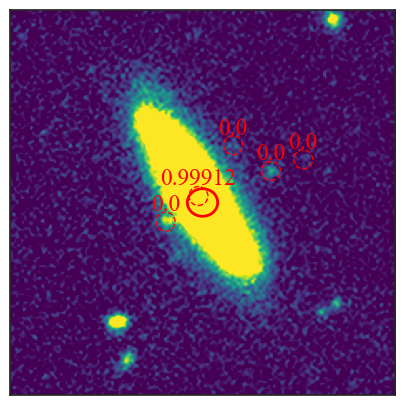

In [7]:
fig = plt.figure(figsize=(5, 5)); ax = plt.subplot()
mean, median, sigma = sigma_clipped_stats(data)
ax.imshow(data, vmin=median-0*sigma, vmax=median+10*sigma, cmap='viridis')

x0, y0 = w.world_to_pixel(co_rad[0])
aper = EllipticalAperture((x0, y0), e_ra*2.15/0.258, e_dec*2.15/0.258, 0)
aper.plot(color='red', linewidth=2)

ax.set_xticks([]); ax.set_yticks([])
size = 30/0.258
ax.set_xlim(x0-size, x0+size); ax.set_ylim(y0-size, y0+size)

for i in range(len(tabo)):
    host_pos = coordinates.SkyCoord(df["ra"][i], 
                                    df["dec"][i], 
                                    unit=(u.deg, u.deg), frame='icrs')
    sky_host_aper = SkyCircularAperture(host_pos, 1.5*u.arcsec)
    host_aper = sky_host_aper.to_pixel(w)
    host_aper.plot(color='red', linewidth=1, linestyle="--")
    x0, y0 = w.world_to_pixel(host_pos)
    plt.text(x0, y0+10, round(df["P_Ox"][i], 5), color="red", ha='center', va='center')
